## Imports Libraries

In [43]:
import os
import json 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Load CSV Files

In [44]:
DATA_PATH="/kaggle/input/datasets/sourabhsaxena55/new-dataset01"
train_df=pd.read_csv(os.path.join(DATA_PATH,"train.csv"))
val_df=pd.read_csv(os.path.join(DATA_PATH,"val.csv"))
test_df=pd.read_csv(os.path.join(DATA_PATH,"test.csv"))

with open(os.path.join(DATA_PATH,"class_names.json"), "r") as f:
    class_names=json.load(f)

num_classes=len(class_names)

## Data Pipeline

In [45]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

def create_dataset(df,training=False):
    image_paths = df['image_path'].values
    labels = df['label'].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths,labels))
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        dataset = dataset.shuffle(1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_dataset = create_dataset(train_df,training=True)
val_dataset = create_dataset(val_df,training=True)
test_dataset=create_dataset(test_df,training=True)

## Load EfficientNetB0

In [46]:
base_model=tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

base_model.trainable=False #Freeze base

##  Build Transfer Learning Model

In [47]:
from tensorflow.keras.applications import EfficientNetB0

# Load pretrained base
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

# Build model properly
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Compile Model

In [48]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [49]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1771611990.667105     123 service.cc:152] XLA service 0x7a0ddc002eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771611990.667152     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771611992.924021     123 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771612004.171111     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


220/220 ━━━━━━━━━━━━━━━━━━━━ 87s 268ms/step - accuracy: 0.6519 - loss: 1.0948 - val_accuracy: 0.7144 - val_loss: 0.7777
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.7048 - loss: 0.8087 - val_accuracy: 0.7250 - val_loss: 0.7208
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.7244 - loss: 0.7497 - val_accuracy: 0.7457 - val_loss: 0.6855
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.7410 - loss: 0.7255 - val_accuracy: 0.7617 - val_loss: 0.6466
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.7392 - loss: 0.7021 - val_accuracy: 0.7577 - val_loss: 0.6412
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.7540 - loss: 0.6726 - val_accuracy: 0.7716 - val_loss: 0.6316
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.7555 - loss: 0.6627 - val_accuracy: 0.7703 - val_loss: 0.6254
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.7446 - loss: 0.6676 - val_accura

## Training Curves

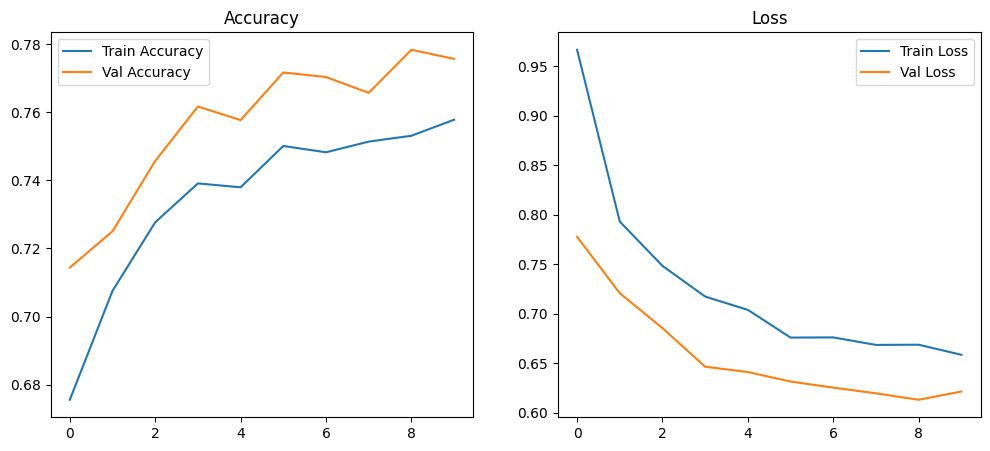

In [50]:
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')
    
    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
    
    plt.show()

plot_training(history)

## Evaluation on Test

In [51]:
test_loss, test_acc = model.evaluate(test_dataset)

print("Test Accuracy:", test_acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - accuracy: 0.7830 - loss: 0.6181
Test Accuracy: 0.7651364207267761
